data shape: (1797, 64)
images shape: (1797, 8, 8)
target shape: (1797,)


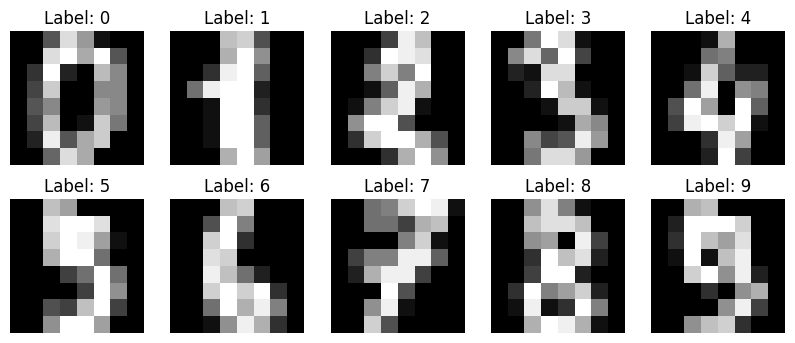

Accuracy for 32 Neural Network: 0.9805555555555555
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.97      0.95        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       0.97      0.94      0.96        36
           7       1.00      1.00      1.00        36
           8       0.94      0.94      0.94        35
           9       1.00      1.00      1.00        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360

Accuracy for 64 Neural Network: 0.9805555555555555
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.94      0

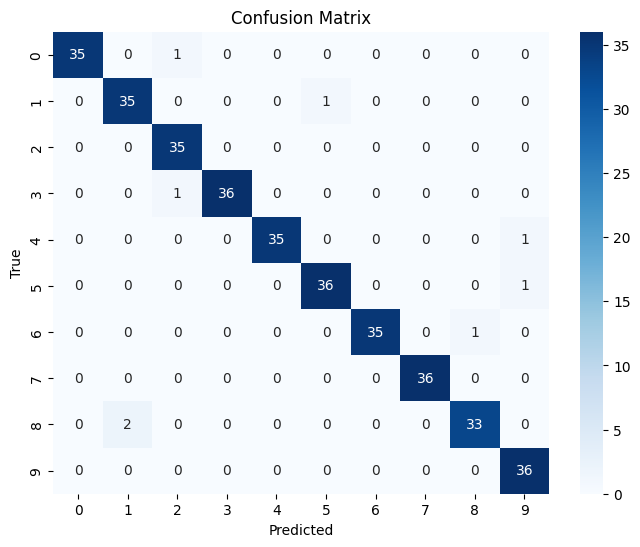

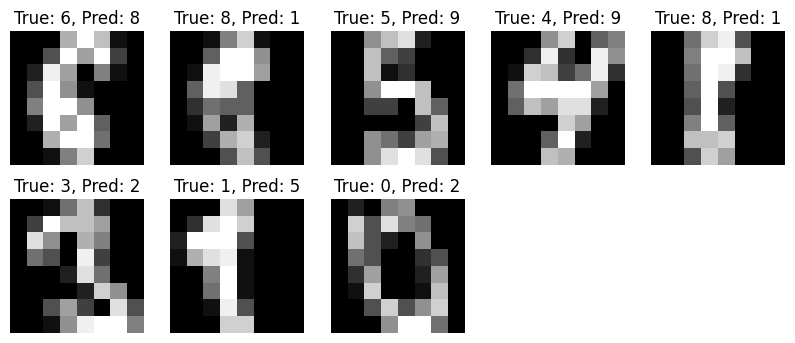

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# загрузить датасет load_digits;
# вывести размеры digits.data, digits.images, digits.target;

digits = load_digits()
print("data shape:", digits.data.shape)
print("images shape:", digits.images.shape)
print("target shape:", digits.target.shape)

# Показываем первые 10 изображений
plt.figure(figsize=(10, 4))
for i in range(10):
 plt.subplot(2, 5, i + 1)
 plt.imshow(digits.images[i], cmap="gray")
 plt.title(f"Label: {digits.target[i]}")
 plt.axis("off")
plt.show()

# разделить данные на train/test;
X = digits.data
y = digits.target
X_train, X_test, y_train, y_test = train_test_split(
 X,
 y,
 test_size=0.2,
 random_state=42,
 stratify=y
)

# выполнить StandardScaler;
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# обучить MLPClassifier с 32, 64, 128 нейронами;
nn_model32 = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    max_iter=500,
    random_state=42)

nn_model64 = MLPClassifier(
 hidden_layer_sizes=(64,),
 activation="relu",
 max_iter=500,
 random_state=42
)

nn_model128 = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    max_iter=500,
    random_state=42)

nn_model32.fit(X_train_scaled, y_train)
nn_predictions32 = nn_model32.predict(X_test_scaled)

nn_model64.fit(X_train_scaled, y_train)
nn_predictions64 = nn_model64.predict(X_test_scaled)

nn_model128.fit(X_train_scaled, y_train)
nn_predictions128 = nn_model128.predict(X_test_scaled)

print("Accuracy for 32 Neural Network:", accuracy_score(y_test, nn_predictions32))
print(classification_report(y_test, nn_predictions32))

print("Accuracy for 64 Neural Network:", accuracy_score(y_test, nn_predictions64))
print(classification_report(y_test, nn_predictions64))

print("Accuracy for 128 Neural Network:", accuracy_score(y_test, nn_predictions128))
print(classification_report(y_test, nn_predictions128))

# сравнить архитектуры (64,) и (64, 32)
# Один скрытый слой
model_one = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    max_iter=500,
    random_state=42
)

# Два скрытых слоя
model_two = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42
)

model_one.fit(X_train_scaled, y_train)
pred_one = model_one.predict(X_test_scaled)

model_two.fit(X_train_scaled, y_train)
pred_two = model_two.predict(X_test_scaled)

print("One hidden layer accuracy:",
      accuracy_score(y_test, pred_one))

print("Two hidden layers accuracy:",
      accuracy_score(y_test, pred_two))


# Ответить письменно: что изменилось? Улучшилось ли качество? Может ли более глубокая сеть переобучиться?
# Модель с двумя скрытыми слоями способна изучать более сложные зависимости в данных.
# В некоторых случаях качество может улучшиться, однако более глубокая сеть обучается дольше и может переобучаться,
# особенно на небольших датасетах.

# 6. вывести accuracy и classification_report.
nn_acc32 = accuracy_score(y_test, nn_predictions32)
nn_acc64 = accuracy_score(y_test, nn_predictions64)
nn_acc128 = accuracy_score(y_test, nn_predictions128)
print("32 Neural Network:", nn_acc32)
print("64 Neural Network:", nn_acc64)
print("128 Neural Network:", nn_acc128)

# 4. Confusion Matrix

accuracies = {
    "32": nn_acc32,
    "64": nn_acc64,
    "128": nn_acc128
}

best_model_name = max(accuracies, key=accuracies.get)

if best_model_name == "32":
    best_model_predictions = nn_predictions32
elif best_model_name == "64":
    best_model_predictions = nn_predictions64
else:
    best_model_predictions = nn_predictions128

print("Best model:", best_model_name)

# Анализ ошибок модели
# Модель чаще всего путает похожие цифры, например 3 и 5 или 8 и 9.
# Причина ошибок — похожие формы цифр и нечеткие изображения в датасете.
wrong_indexes = np.where(y_test != best_model_predictions)[0]

plt.figure(figsize=(10, 4))

for i, idx in enumerate(wrong_indexes[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(8, 8), cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {best_model_predictions[idx]}")
    plt.axis("off")

plt.show()


In [ ]:
# Теоретические вопросы
# 1. Что такое искусственный нейрон?
# базовый элемент нейросети. принимает вход, перемножает их значения и весы и добавляет смещение

# 2. Что такое вес в нейроне?
# коэффициент указывающий значимость входного признака

# 3. Что такое bias?
# коэффициент смещения. нужен для нахождение более точные решения

# 4. Что такое функция активации?
# определяет значимость/силу нейрона на основе входных значений.

# 5. Чем ReLU отличается от step function?
# ReLU работает только с положительными числами, имеет диапозон от 0 до максимального значения

# 6. Что такое loss?
# коэффициент между кол-вом правильных ответов модели и кол-вом реальных правильных ответов.
# чем ниже loss - тем точнее модель

# 7. Что такое epoch?
# кол-во проходов по датасету.

# 8. Что такое learning rate?
# скорость обучения. если скорость большая - обучение не точное. если медленное - более точное

# 9. Почему изображение 8x8 превращается в 64 признака?
# кол-во пикселей по ширине и длине перемножаются и получается 64 пикселей, а каждый пиксель - отдельный числовой признак

# 10. Почему нейронная сеть не всегда лучше классических моделей?
# нейросети обучаются дольше, требуют больше данных. поэтому при работе с аудио-видео-изображениями лучше нейросети, а при работе с таблицами лучше использовать другие модели

# 11. Почему CNN является следующим логичным шагом после MLP?
# cnn требует меньше параметров и лучше считывает формы, границы и текстуры обьектов на изображении
